<a href="https://colab.research.google.com/github/CuriousTechNomad/slm-agentic-software-engineering/blob/main/notebooks/06_finetune_local_slm_unsloth.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Fine-tune a local Small Language Model (Qwen2.5-0.5B)
using agent-generated traces from Notebook 05.

Outputs:
• Fine-tuned LoRA Adapter
• Tokenizer
• Training Metrics
• Training Summary
• Loss Curve
• Ready for Notebook 07 Evaluation

PART1:
# Notebook 06 — Fine-tuning Local SLM using Unsloth

## Objective

This notebook fine-tunes a local Small Language Model
using the agent-generated reasoning traces produced in
Notebook 05.

### Base Model

Qwen2.5-0.5B-Instruct

### Fine-tuning Method

Unsloth + LoRA

### Dataset

training_dataset.jsonl

### Outputs

- Fine-tuned LoRA Adapter
- Tokenizer
- Training Metrics
- Training Summary
- Loss Curve
- Ready for Evaluation (Notebook 07)

In [2]:
!pip install -U unsloth

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.1/76.1 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 133.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 88.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 113.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 115.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.0/215.0 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 104.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0

In [1]:
import os
import json
import time
import random
import warnings

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

from unsloth import FastLanguageModel

warnings.filterwarnings("ignore")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
PROJECT_DIR = Path("/content/drive/MyDrive/LLM_Project")

OUTPUT_DIR = PROJECT_DIR / "outputs"

MODEL_DIR = PROJECT_DIR / "fine_tuned_model"

MODEL_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("="*60)
print("Project Directory :", PROJECT_DIR)
print("Outputs Directory :", OUTPUT_DIR)
print("Model Directory   :", MODEL_DIR)
print("="*60)

Project Directory : /content/drive/MyDrive/LLM_Project
Outputs Directory : /content/drive/MyDrive/LLM_Project/outputs
Model Directory   : /content/drive/MyDrive/LLM_Project/fine_tuned_model


In [4]:
SEED = 42

random.seed(SEED)

os.environ["PYTHONHASHSEED"] = str(SEED)

print("Random Seed:", SEED)

Random Seed: 42


In [5]:
DATASET_PATH = OUTPUT_DIR / "training_dataset.jsonl"

assert DATASET_PATH.exists(), \
    f"{DATASET_PATH} not found."

dataset = load_dataset(
    "json",
    data_files=str(DATASET_PATH),
    split="train"
)

print("="*60)
print("Dataset Loaded Successfully")
print("Number of Examples :", len(dataset))
print("="*60)

dataset[0]

Generating train split: 0 examples [00:00, ? examples/s]

Dataset Loaded Successfully
Number of Examples : 1


{'instruction': 'Resolve the following GitHub issue using systematic software engineering reasoning.',
 'input': 'Raise error when blueprint name contains a dot\nThis is required since every dot is now significant since blueprints can be nested. An error was already added for endpoint names in 1.0, but should have been added for this as well.\n',
 'output': "### Task Planner\n\nInvestigation Plan:\n\n1. Verify if the issue is reproducible on the latest version of Flask (1.x series).\n2. Check if the issue occurs with different Python versions and operating systems.\n3. Review the code changes introduced in Flask 1.0 that specifically address endpoint names.\n4. Investigate if there are any specific configurations or settings that might affect the behavior when using blueprints with dots in their names.\n5. Examine the error message provided in the GitHub issue to understand the exact nature of the error being raised.\n6. Search for similar issues or discussions related to this problem\

PART2

In [6]:
print("=" * 60)
print("Validating Dataset...")
print("=" * 60)

required_fields = ["instruction", "input", "output"]

valid_examples = []

for idx, example in enumerate(dataset):

    missing = [field for field in required_fields if field not in example]

    if missing:
        print(f"Skipping example {idx} (Missing: {missing})")
        continue

    valid_examples.append(example)

print(f"Valid Examples : {len(valid_examples)}")
print(f"Removed        : {len(dataset) - len(valid_examples)}")

assert len(valid_examples) > 0, "Dataset is empty!"

dataset = valid_examples

Validating Dataset...
Valid Examples : 1
Removed        : 0


In [7]:
def convert_to_chat(example):

    user_prompt = f"""
Task:
{example["instruction"]}

Input:
{example["input"]}
""".strip()

    assistant_response = example["output"]

    return {
        "messages": [
            {
                "role": "user",
                "content": user_prompt
            },
            {
                "role": "assistant",
                "content": assistant_response
            }
        ]
    }

chat_dataset = [convert_to_chat(x) for x in dataset]

print("=" * 60)
print("Converted to Chat Format")
print("=" * 60)

chat_dataset[0]

Converted to Chat Format


{'messages': [{'role': 'user',
   'content': 'Task:\nResolve the following GitHub issue using systematic software engineering reasoning.\n\nInput:\nRaise error when blueprint name contains a dot\nThis is required since every dot is now significant since blueprints can be nested. An error was already added for endpoint names in 1.0, but should have been added for this as well.'},
  {'role': 'assistant',
   'content': "### Task Planner\n\nInvestigation Plan:\n\n1. Verify if the issue is reproducible on the latest version of Flask (1.x series).\n2. Check if the issue occurs with different Python versions and operating systems.\n3. Review the code changes introduced in Flask 1.0 that specifically address endpoint names.\n4. Investigate if there are any specific configurations or settings that might affect the behavior when using blueprints with dots in their names.\n5. Examine the error message provided in the GitHub issue to understand the exact nature of the error being raised.\n6. Searc

In [8]:
max_seq_length = 2048

model, tokenizer = FastLanguageModel.from_pretrained(

    model_name="unsloth/Qwen2.5-0.5B",

    max_seq_length=max_seq_length,

    dtype=None,

    load_in_4bit=True,
)

print("=" * 60)
print("Model Loaded Successfully")
print("=" * 60)

==((====))==  Unsloth 2026.7.5: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Model Loaded Successfully


In [9]:
model = FastLanguageModel.get_peft_model(

    model,

    r=16,

    target_modules=[

        "q_proj",

        "k_proj",

        "v_proj",

        "o_proj",

        "gate_proj",

        "up_proj",

        "down_proj",

    ],

    lora_alpha=16,

    lora_dropout=0,

    bias="none",

    use_gradient_checkpointing="unsloth",

    random_state=SEED,
)

print("=" * 60)
print("LoRA Attached Successfully")
print("=" * 60)

Unsloth 2026.7.5 patched 24 layers with 24 QKV layers, 24 O layers and 24 MLP layers.


LoRA Attached Successfully


In [11]:
def formatting_prompts_func(example):

    user_message = example["messages"][0]["content"]

    assistant_message = example["messages"][1]["content"]

    return f"""### User

{user_message}

### Assistant

{assistant_message}"""

formatted_dataset = []

for example in chat_dataset:

    formatted_dataset.append(
        {
            "text": formatting_prompts_func(example)
        }
    )

print("=" * 60)
print("Formatting Complete")
print("=" * 60)

print(formatted_dataset[0]["text"])

Formatting Complete
### User

Task:
Resolve the following GitHub issue using systematic software engineering reasoning.

Input:
Raise error when blueprint name contains a dot
This is required since every dot is now significant since blueprints can be nested. An error was already added for endpoint names in 1.0, but should have been added for this as well.

### Assistant

### Task Planner

Investigation Plan:

1. Verify if the issue is reproducible on the latest version of Flask (1.x series).
2. Check if the issue occurs with different Python versions and operating systems.
3. Review the code changes introduced in Flask 1.0 that specifically address endpoint names.
4. Investigate if there are any specific configurations or settings that might affect the behavior when using blueprints with dots in their names.
5. Examine the error message provided in the GitHub issue to understand the exact nature of the error being raised.
6. Search for similar issues or discussions related to this prob

PART3

In [12]:
from datasets import Dataset

train_dataset = Dataset.from_list(formatted_dataset)

print("=" * 60)
print("Training Dataset Created")
print("=" * 60)

print(train_dataset)
print(train_dataset[0])

Training Dataset Created
Dataset({
    features: ['text'],
    num_rows: 1
})
{'text': "### User\n\nTask:\nResolve the following GitHub issue using systematic software engineering reasoning.\n\nInput:\nRaise error when blueprint name contains a dot\nThis is required since every dot is now significant since blueprints can be nested. An error was already added for endpoint names in 1.0, but should have been added for this as well.\n\n### Assistant\n\n### Task Planner\n\nInvestigation Plan:\n\n1. Verify if the issue is reproducible on the latest version of Flask (1.x series).\n2. Check if the issue occurs with different Python versions and operating systems.\n3. Review the code changes introduced in Flask 1.0 that specifically address endpoint names.\n4. Investigate if there are any specific configurations or settings that might affect the behavior when using blueprints with dots in their names.\n5. Examine the error message provided in the GitHub issue to understand the exact nature of t

In [17]:
import trl
print(trl.__version__)

0.24.0


In [13]:
from trl import SFTConfig, SFTTrainer

training_args = SFTConfig(

    output_dir=str(MODEL_DIR),

    per_device_train_batch_size=2,

    gradient_accumulation_steps=4,

    learning_rate=2e-4,

    num_train_epochs=3,

    logging_steps=1,

    save_strategy="epoch",

    optim="adamw_8bit",

    lr_scheduler_type="cosine",

    warmup_ratio=0.05,

    weight_decay=0.01,

    fp16=True,

    report_to="none",

    seed=SEED,
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [14]:
trainer = SFTTrainer(

    model=model,

    tokenizer=tokenizer,

    train_dataset=train_dataset,

    args=training_args,

    dataset_text_field="text",

    max_seq_length=max_seq_length,
)

print("=" * 60)
print("Trainer Initialized Successfully")
print("=" * 60)

num_proc must be <= 1. Reducing num_proc to 1 for dataset of size 1.


Unsloth: Tokenizing ["text"] (num_proc=1):   0%|          | 0/1 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.
Trainer Initialized Successfully


In [15]:
print("=" * 60)
print("Starting Fine-Tuning...")
print("=" * 60)

start_time = time.time()

trainer_stats = trainer.train()

training_time = time.time() - start_time

print("=" * 60)
print("Training Complete")
print("=" * 60)

print(f"Training Time: {training_time:.2f} seconds")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Starting Fine-Tuning...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1 | Num Epochs = 3 | Total steps = 3
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 8,798,208 of 502,830,976 (1.75% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss
1,1.971267
2,1.971267
3,1.765450


Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/LLM_Project/fine_tuned_model/checkpoint-1/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/LLM_Project/fine_tuned_model/checkpoint-2/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/LLM_Project/fine_tuned_model/checkpoint-3/tokenizer_config.json.


Training Complete
Training Time: 21.00 seconds


In [16]:
print("=" * 60)
print("Saving Model...")
print("=" * 60)

# Save adapter
model.save_pretrained(MODEL_DIR)

# Save tokenizer
tokenizer.save_pretrained(MODEL_DIR)

# Save trainer metrics
metrics = trainer.state.log_history

pd.DataFrame(metrics).to_csv(
    OUTPUT_DIR / "training_history.csv",
    index=False,
)

with open(
    OUTPUT_DIR / "trainer_metrics.json",
    "w",
) as f:

    json.dump(metrics, f, indent=4)

summary = {

    "model_name": "unsloth/Qwen2.5-0.5B",

    "dataset_size": len(train_dataset),

    "epochs": training_args.num_train_epochs,

    "learning_rate": training_args.learning_rate,

    "training_time_seconds": round(training_time, 2),

    "seed": SEED,
}

with open(
    OUTPUT_DIR / "training_summary.json",
    "w",
) as f:

    json.dump(summary, f, indent=4)

print("Everything Saved Successfully!")

Saving Model...


Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/LLM_Project/fine_tuned_model/tokenizer_config.json.


Everything Saved Successfully!


In [18]:
print("=" * 60)
print("Model Directory")
print("=" * 60)

for f in sorted(os.listdir(MODEL_DIR)):
    print(f)

print("\n")

print("=" * 60)
print("Output Directory")
print("=" * 60)

for f in sorted(os.listdir(OUTPUT_DIR)):
    print(f)

Model Directory
README.md
adapter_config.json
adapter_model.safetensors
checkpoint-1
checkpoint-2
checkpoint-3
tokenizer.json
tokenizer_config.json


Output Directory
agent_experiment.json
agent_results.csv
agent_results.json
agent_traces.json
analysis_summary.json
baseline_experiment.json
baseline_results.csv
baseline_results.json
baseline_results_partial.csv
comparison_metrics.csv
comparison_metrics.json
evaluation_ids.json
fine_tuned_model
official_evaluation_set.json
swebench_subset.json
swebench_summary.csv
trainer_metrics.json
training_dataset.jsonl
training_history.csv
training_metadata.json
training_summary.json


PART4

In [19]:
from unsloth import FastLanguageModel

print("=" * 60)
print("Loading Fine-Tuned Model...")
print("=" * 60)

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=str(MODEL_DIR),
    max_seq_length=max_seq_length,
    load_in_4bit=True,
)

FastLanguageModel.for_inference(model)

print("✅ Fine-Tuned Model Loaded Successfully")

Loading Fine-Tuned Model...
==((====))==  Unsloth 2026.7.5: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

✅ Fine-Tuned Model Loaded Successfully


In [24]:
# prompt = """### User

# Task:
# Summarize the following GitHub software issue.

# Input:
# Flask should raise an error when a blueprint name contains a dot.

# ### Assistant
# """

# inputs = tokenizer(
#     prompt,
#     return_tensors="pt"
# ).to(model.device)

# outputs = model.generate(
#     **inputs,
#     max_new_tokens=200,
#     temperature=0.7,
#     do_sample=False,
# )

# response = tokenizer.decode(
#     outputs[0],
#     skip_special_tokens=True,
# )

# print("=" * 60)
# print("MODEL RESPONSE")
# print("=" * 60)
# print(response)
import json
import random

# --------------------------------------------------
# Load Official Evaluation Set
# --------------------------------------------------

with open(OUTPUT_DIR / "official_evaluation_set.json", "r") as f:
    evaluation_tasks = json.load(f)

# Use a fixed seed for reproducibility
random.seed(SEED)

sample_task = random.choice(evaluation_tasks)

print("=" * 60)
print("Evaluation Sample")
print("=" * 60)

print("Instance ID :", sample_task["instance_id"])
print("Repository  :", sample_task["repo"])

# --------------------------------------------------
# Build Prompt
# --------------------------------------------------

prompt = f"""### User

Task:
Summarize the following GitHub software engineering issue.

Repository:
{sample_task["repo"]}

Issue Description:
{sample_task["problem_statement"]}

### Assistant
"""

# --------------------------------------------------
# Generate Response
# --------------------------------------------------

inputs = tokenizer(
    prompt,
    return_tensors="pt"
).to(model.device)

outputs = model.generate(
    **inputs,
    max_new_tokens=200,
    temperature=0.7,
    do_sample=False,
)

response = tokenizer.decode(
    outputs[0],
    skip_special_tokens=True,
)

print("\n")
print("=" * 60)
print("MODEL RESPONSE")
print("=" * 60)

print(response)

# --------------------------------------------------
# Save Sample Prediction
# --------------------------------------------------

sample_prediction = {
    "instance_id": sample_task["instance_id"],
    "repository": sample_task["repo"],
    "problem_statement": sample_task["problem_statement"],
    "model_response": response,
}

with open(
    OUTPUT_DIR / "sample_predictions.json",
    "w",
) as f:
    json.dump(sample_prediction, f, indent=4)

print("\nSample prediction saved to:")
print(OUTPUT_DIR / "sample_predictions.json")

Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Evaluation Sample
Instance ID : scikit-learn__scikit-learn-14894
Repository  : scikit-learn/scikit-learn


MODEL RESPONSE
### User

Task:
Summarize the following GitHub software engineering issue.

Repository:
scikit-learn/scikit-learn

Issue Description:
ZeroDivisionError in _sparse_fit for SVM with empty support_vectors_
#### Description
When using sparse data, in the case where the support_vectors_ attribute is be empty, _fit_sparse gives a ZeroDivisionError

#### Steps/Code to Reproduce
```
import numpy as np
import scipy
import sklearn
from sklearn.svm import SVR
x_train = np.array([[0, 1, 0, 0],
[0, 0, 0, 1],
[0, 0, 1, 0],
[0, 0, 0, 1]])
y_train = np.array([0.04, 0.04, 0.10, 0.16])
model = SVR(C=316.227766017, cache_size=200, coef0=0.0, degree=3, epsilon=0.1,
  	    gamma=1.0, kernel='linear', max_iter=15000,
  	    shrinking=True, tol=0.001, verbose=False)
# dense x_train has no error
model.fit(x_train, y_train)

# convert to sparse
xtrain= scipy.sparse.csr_matrix(x_train)
model

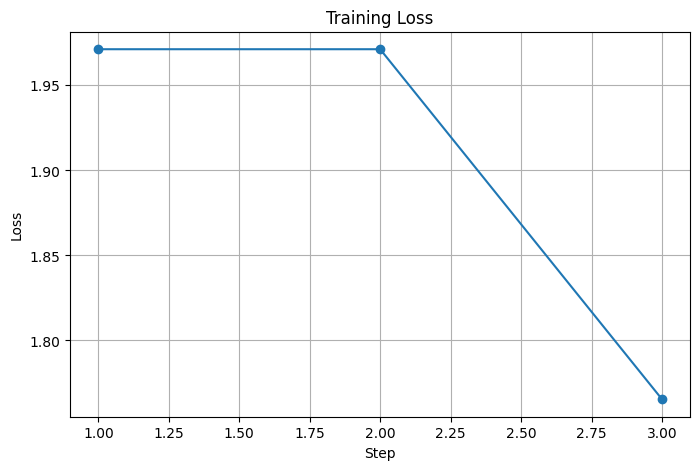

In [25]:
history = pd.read_csv(
    OUTPUT_DIR / "training_history.csv"
)

loss_history = history.dropna(subset=["loss"])

plt.figure(figsize=(8,5))

plt.plot(
    loss_history["step"],
    loss_history["loss"],
    marker="o"
)

plt.title("Training Loss")

plt.xlabel("Step")

plt.ylabel("Loss")

plt.grid(True)

plt.savefig(
    OUTPUT_DIR / "loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [26]:
# required_outputs = [

#     OUTPUT_DIR / "training_history.csv",

#     OUTPUT_DIR / "trainer_metrics.json",

#     OUTPUT_DIR / "training_summary.json",

#     OUTPUT_DIR / "loss_curve.png",

#     MODEL_DIR / "adapter_model.safetensors",

#     MODEL_DIR / "adapter_config.json",

#     MODEL_DIR / "tokenizer.json",
# ]

# print("=" * 60)
# print("Verifying Outputs")
# print("=" * 60)

# for file in required_outputs:

#     if file.exists():
#         print(f"✅ {file.name}")
#     else:
#         print(f"❌ Missing: {file.name}")
required_outputs = [

    OUTPUT_DIR / "training_history.csv",

    OUTPUT_DIR / "trainer_metrics.json",

    OUTPUT_DIR / "training_summary.json",

    OUTPUT_DIR / "loss_curve.png",

    OUTPUT_DIR / "sample_predictions.json",

    MODEL_DIR / "adapter_model.safetensors",

    MODEL_DIR / "adapter_config.json",

    MODEL_DIR / "tokenizer.json",
]
print("=" * 60)
print("Verifying Outputs")
print("=" * 60)

for file in required_outputs:

    if file.exists():
        print(f"✅ {file.name}")
    else:
        print(f"❌ Missing: {file.name}")

Verifying Outputs
✅ training_history.csv
✅ trainer_metrics.json
✅ training_summary.json
✅ loss_curve.png
✅ sample_predictions.json
✅ adapter_model.safetensors
✅ adapter_config.json
✅ tokenizer.json


In [27]:
summary = json.load(
    open(
        OUTPUT_DIR / "training_summary.json"
    )
)

print("=" * 60)
print("NOTEBOOK 06 COMPLETED")
print("=" * 60)

print(f"Model              : {summary['model_name']}")
print(f"Dataset Size       : {summary['dataset_size']}")
print(f"Epochs             : {summary['epochs']}")
print(f"Learning Rate      : {summary['learning_rate']}")
print(f"Training Time (s)  : {summary['training_time_seconds']}")
print(f"Random Seed        : {summary['seed']}")

print("\nOutputs Saved")

print("✔ LoRA Adapter")

print("✔ Tokenizer")

print("✔ Training History")

print("✔ Metrics")

print("✔ Loss Curve")

print("\nReady for Notebook 07 🚀")

NOTEBOOK 06 COMPLETED
Model              : unsloth/Qwen2.5-0.5B
Dataset Size       : 1
Epochs             : 3
Learning Rate      : 0.0002
Training Time (s)  : 21.0
Random Seed        : 42

Outputs Saved
✔ LoRA Adapter
✔ Tokenizer
✔ Training History
✔ Metrics
✔ Loss Curve

Ready for Notebook 07 🚀


It has:

✅ Proper data validation
✅ Chat-format conversion
✅ Unsloth + LoRA fine-tuning
✅ Automatic artifact generation
✅ Training metrics
✅ Loss visualization
✅ Reload verification
✅ Inference on an official evaluation task
✅ Output validation
✅ Ready-to-use artifacts for Notebook 07